In [1]:
import uproot as ur
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [94]:
# Load the ROOT file and access the tree

run_name = '1200V40mV920'

filename = {'1000V20mV920':'test_run_thr20_20260325_134741',
            '1050V20mV999':'test_run_thr20_20260325_140241',
            '1110V40mV999':'test_run_thr40_20260325_141817',
            '1150V40mV999':'test_run_thr40_20260325_142328',
            '1200V40mV999':'test_run_thr40_20260325_142934',
            '1250V40mV999':'test_run_thr40_20260325_143320',
            '1050V20mV920':'test_run_thr20_20260325_150454',
            '1100V40mV920':'test_run_thr40_20260325_150911',
            '1150V40mV920':'test_run_thr40_20260325_151213',
            '1200V40mV920':'test_run_thr40_20260325_151728',
            '1250V40mV000':'test_run_thr40_20260325_152254'            # anomalously high rate - garbage run
            }[run_name]

file_path = f'I:/fd2_data/{filename}.root'
data_file = ur.open(file_path)
channels = [11] # List of active channels to analyze
period = 100000 # Flash period in ns

In [95]:
# check top level keys
data_file.keys()

['pmt_events;1', 'led_events;1']

In [96]:
# list keys in the pmt_events tree
print([key for key in list(data_file['pmt_events'].keys())])

['event_type', 'channel', 'status', 'length', 'adc', 'pmt_time', 'time_coarse', 'time_fine', 'tdc_coarse', 'tdc_start', 'tdc_stop', 'crc']


In [97]:
# Create numpy arrays for each branch of interest

adc_values = data_file['pmt_events']['adc'].array(library='np').flatten()
channel_values = data_file['pmt_events']['channel'].array(library='np').flatten()
pmt_time_values = data_file['pmt_events']['pmt_time'].array(library='np').flatten()
time_coarse_values = data_file['pmt_events']['time_coarse'].array(library='np').flatten()
time_fine_values = data_file['pmt_events']['time_fine'].array(library='np').flatten()
tdc_start_values = data_file['pmt_events']['tdc_start'].array(library='np').flatten()
tdc_stop_values = data_file['pmt_events']['tdc_stop'].array(library='np').flatten()
tot_values = tdc_stop_values - tdc_start_values

data = {
    'adc': adc_values,
    'channel': channel_values,
    'pmt_time': pmt_time_values,
    'time_coarse': time_coarse_values,
    'time_fine': time_fine_values,
    'tdc_start': tdc_start_values,
    'tdc_stop': tdc_stop_values,
    'tot_values': tot_values,}

In [98]:
# Check properties of the data arrays

for key, array in data.items():
    print(f'{key}: shape={array.shape}, len={len(array)}, min={np.min(array)}, max={np.max(array)}, mean={np.mean(array)}, std={np.std(array)}, type={array.dtype}')

# Confirm meaning of the time data:
# time_coarse: 16 bit unsigned int, counts of 2^28 * 4 ns clock -> LSB = 1.07 s
# time_fine: 32 bit unsigned int, counts of 4 ns clock -> LSB = 4 ns (only lower 28 bits used)
# pmt_time: 32 bit unsigned int, time_coarse * 2^28 + time_fine, counts of 4 ns clock -> LSB = 4 ns
# tdc_start: 4 bit unsigned int, counts of 0.25 ns clock -> LSB = 0.25 ns

check_pmt_time_values = np.uint64(time_coarse_values) * (2**28) + time_fine_values
# Check that pmt_time matches calculated value
if np.array_equal(pmt_time_values, check_pmt_time_values):
    print("pmt_time matches calculated value from time_coarse and time_fine")
else:
    print("pmt_time does NOT match calculated value from time_coarse and time_fine")

adc: shape=(26482,), len=26482, min=265, max=3912, mean=346.32527754701306, std=92.91613248178342, type=int64
channel: shape=(26482,), len=26482, min=11, max=11, mean=11.0, std=0.0, type=int64
pmt_time: shape=(26482,), len=26482, min=12605039784903, max=12609960434187, mean=12607274301675.406, std=1503596850.583767, type=int64
time_coarse: shape=(26482,), len=26482, min=46957, max=46975, mean=46965.25371950759, std=5.618394496548533, type=int64
time_fine: shape=(26482,), len=26482, min=5693, max=268434498, mean=135003323.68971378, std=77038742.75077131, type=int64
tdc_start: shape=(26482,), len=26482, min=0, max=14, mean=6.3457065176346195, std=3.937881727557171, type=int64
tdc_stop: shape=(26482,), len=26482, min=0, max=14, mean=7.3845630994637865, std=4.23524511248967, type=int64
tot_values: shape=(26482,), len=26482, min=-14, max=14, mean=1.038856581829167, std=5.833104835540316, type=int64
pmt_time matches calculated value from time_coarse and time_fine


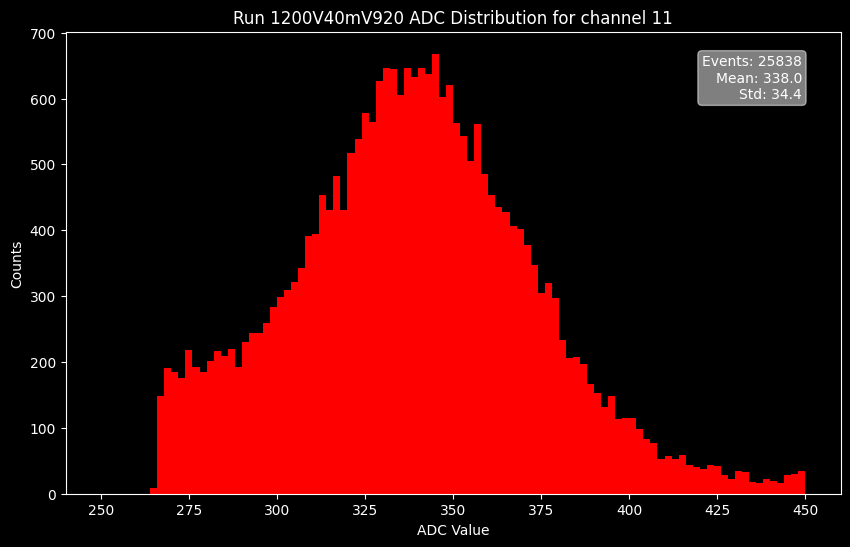

In [99]:
# plot adc distribution for the first active channel
ic = 0
mask = (channel_values == channels[ic])
# fill histogram
plt.figure(figsize=(10, 6))
plt.hist(adc_values[mask], bins=100, range=(250, 450), color='red')
# show number of events, mean and standard deviation, for values between 250 and 450
mask2 = ((adc_values[mask] >= 250) & (adc_values[mask] <= 450))
# show number of events, mean and standard deviation for values between 250 and 450 in a box in upper right of plot
n_evt = np.sum(mask2)
mean = np.mean(adc_values[mask][mask2])
std = np.std(adc_values[mask][mask2])
textstr = '\n'.join((
    f'Events: {n_evt}',
    f'Mean: {mean:.1f}',
    f'Std: {std:.1f}'))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)

# overlay a vertical line for the threshold
#plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
#plt.legend()
#plt.yscale('log')
plt.xlabel('ADC Value')
plt.ylabel('Counts')
plt.title(f'Run {run_name} ADC Distribution for channel {channels[ic]}')
plt.savefig(f'I:/fd2_analyses/adc_distribution_run{run_name}_chan{channels[ic]:02d}.png')
plt.show()

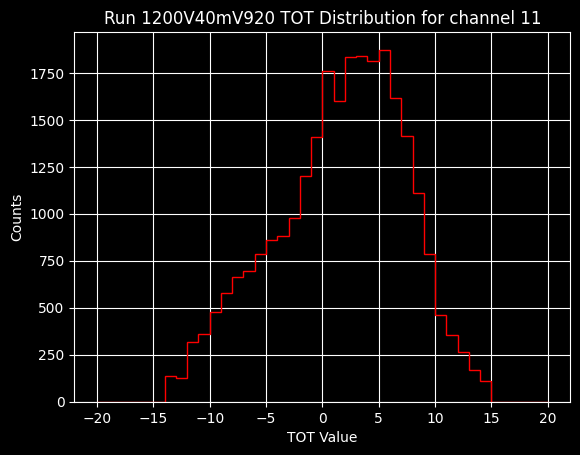

In [100]:
# plot tot distribution for the first active channel
ic = 0
mask = (channel_values == channels[ic])
plt.hist(tot_values[mask], bins=40, range=(-20, 20), histtype='step', color='red')
# overlay a vertical line for the threshold
# plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
#plt.legend()
#plt.yscale('log')
plt.xlabel('TOT Value')
plt.ylabel('Counts')
plt.title(f'Run {run_name} TOT Distribution for channel {channels[ic]}')
plt.grid(True)
plt.savefig(f'I:/fd2_analyses/tot_distribution_run{run_name}_chan{channels[ic]:02d}.png')
plt.show()

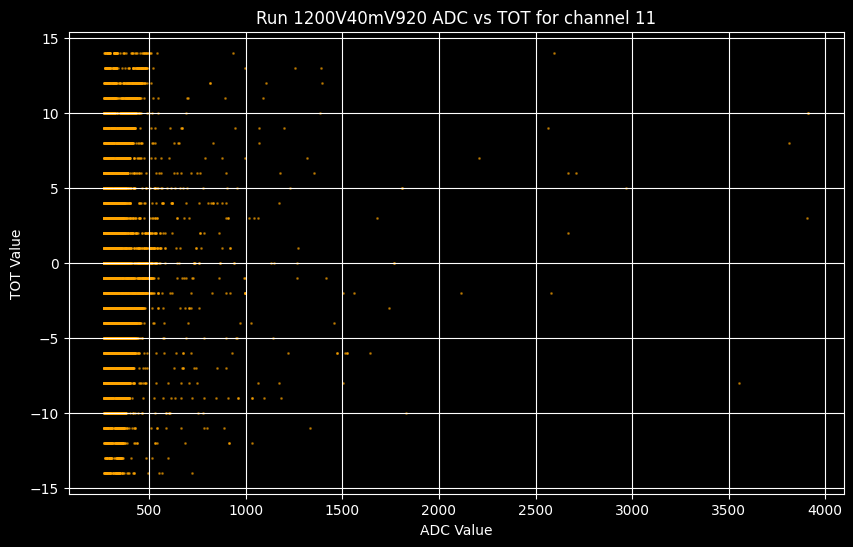

In [101]:
# show a scatter plot of ADC vs TOT for the first active channel
ic = 0
mask = (channel_values == channels[ic])
plt.figure(figsize=(10, 6))
plt.scatter(adc_values[mask], tot_values[mask], s=1, alpha=0.5, color='orange')
plt.xlabel('ADC Value')
plt.ylabel('TOT Value')
plt.title(f'Run {run_name} ADC vs TOT for channel {channels[ic]}')
plt.grid(True)
plt.savefig(f'I:/fd2_analyses/adc_vs_tot_run{run_name}_chan{channels[ic]:02d}.png')
plt.show()

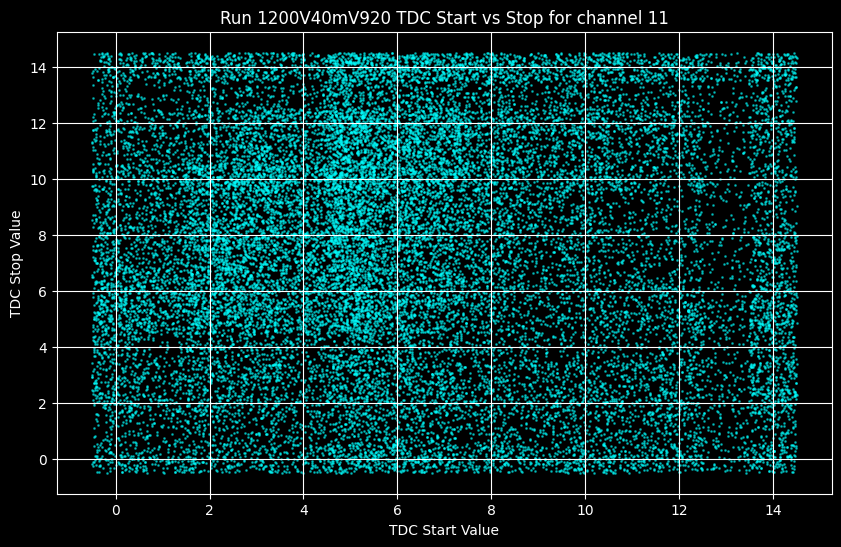

In [102]:
# show a scatter plot of tdc_start vs tdc_stop for the first active channel... add noise to see density
ic = 0
mask = (channel_values == channels[ic])
plt.figure(figsize=(10, 6))
# smear the integers to see density
smeared_start = tdc_start_values[mask] + np.random.uniform(-0.5,0.5,len(tdc_start_values[mask]))
smeared_stop = tdc_stop_values[mask] + np.random.uniform(-0.5,0.5,len(tdc_stop_values[mask]))
plt.scatter(smeared_start,smeared_stop, s=1  , alpha=0.5, color='cyan')
plt.xlabel('TDC Start Value')
plt.ylabel('TDC Stop Value')
plt.title(f'Run {run_name} TDC Start vs Stop for channel {channels[ic]}')
plt.grid(True)
plt.savefig(f'I:/fd2_analyses/tdc_start_vs_stop_run{run_name}_chan{channels[ic]:02d}.png')
plt.show()

Time Range: 0 to 19.68


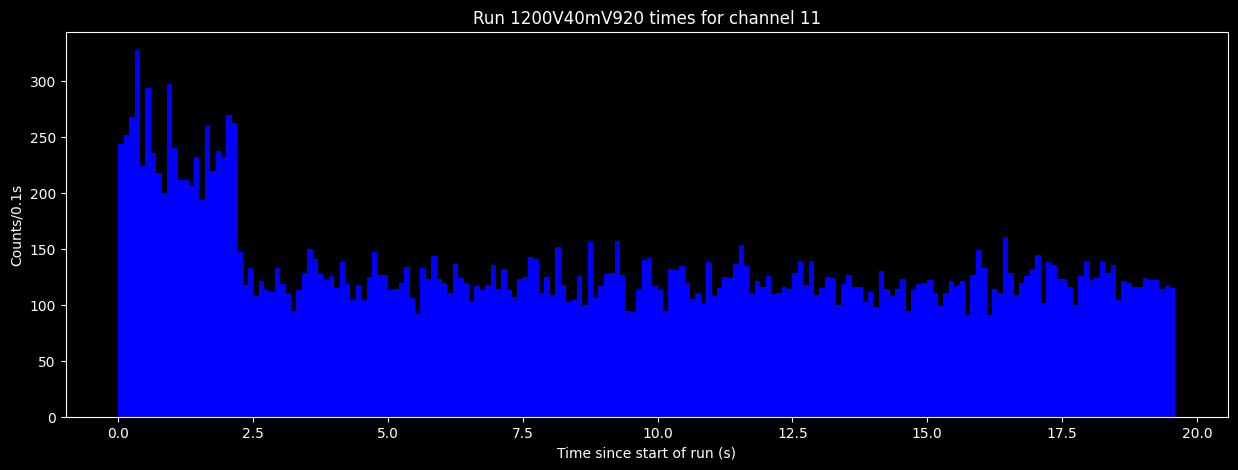

In [103]:
# plot the pmt time distribution with respect to the first signal
ic = 0
mask = (channel_values == channels[ic])

time_min = np.min(pmt_time_values[mask])*4E-9
time_max = np.max(pmt_time_values[mask])*4E-9
print(f"Time Range: 0 to {time_max-time_min:0.2f}")

# make the plot wider
plt.figure(figsize=(15, 5))
plt.hist(pmt_time_values[mask]*4E-9-time_min, bins=np.arange(0.,time_max-time_min,0.1), color='blue')
#plt.yscale('log')
plt.xlabel('Time since start of run (s)')
plt.ylabel('Counts/0.1s')
plt.title(f'Run {run_name} times for channel {channels[ic]}')
#plt.grid(True)
plt.savefig(f'I:/fd2_analyses/time_distribution_run{run_name}_chan{channels[ic]:02d}.png')
plt.show()

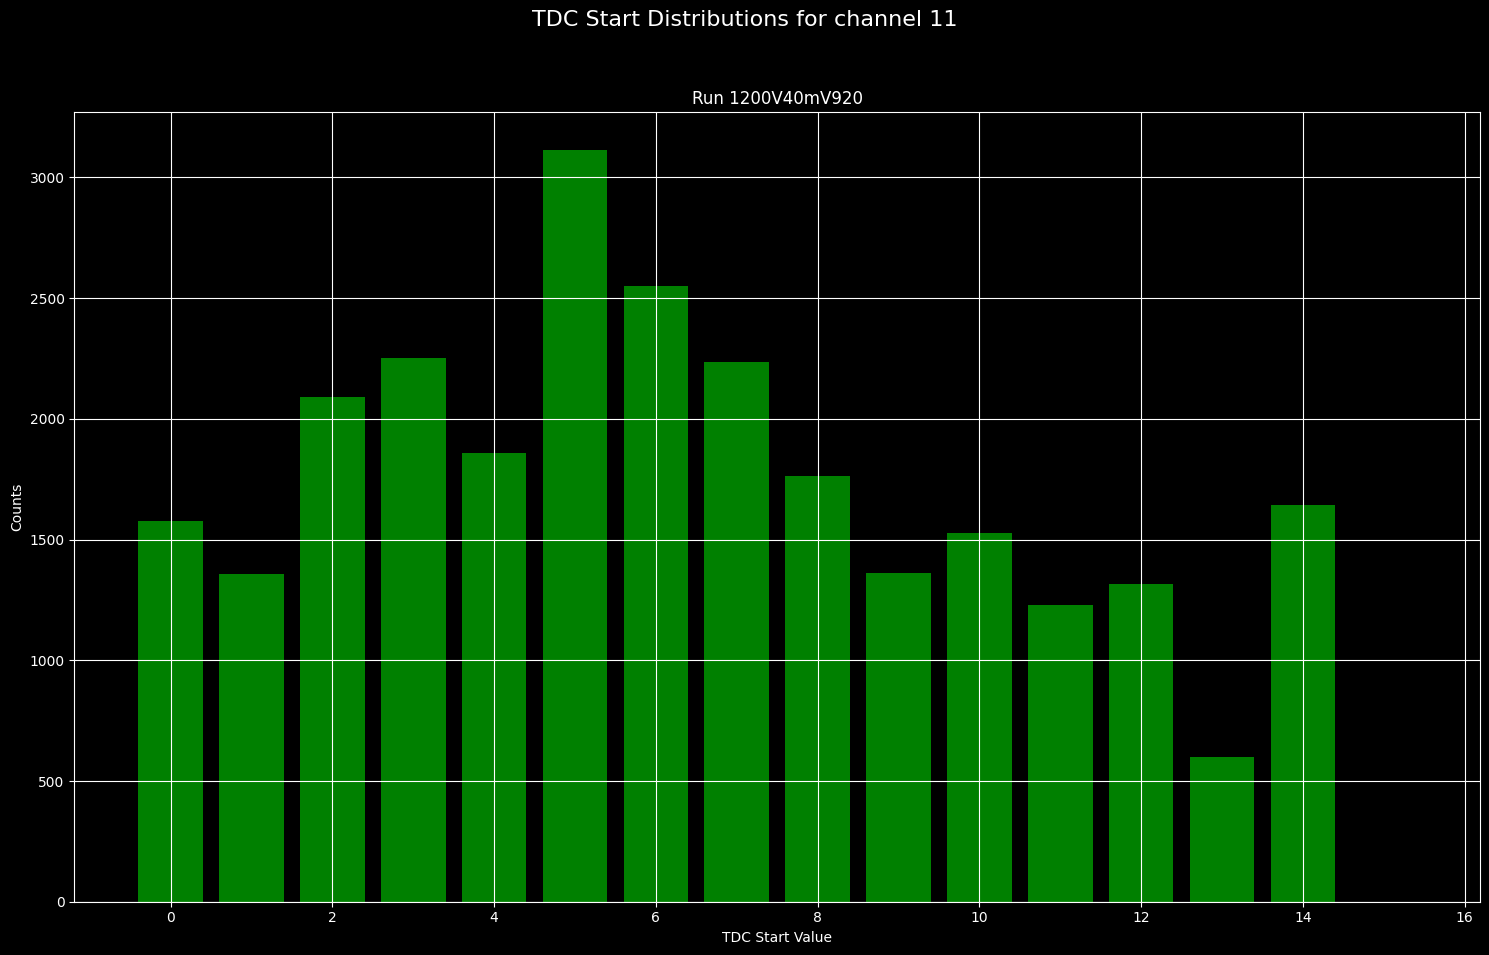

In [104]:
# Show the distribution for tdc_start
# The tdc_start value is a 4 bit number (0 to 15) so we can use 15 bins

ic = 0  # channel index to plot

fig, axs = plt.subplots(1, 1, figsize=(15, 10))
fig.suptitle(f'TDC Start Distributions for channel {channels[ic]}', fontsize=16)
axs.hist(tdc_start_values[mask], bins= np.arange(0, 17, 1), color='green', align='left', rwidth=0.8)
axs.set_title(f'Run {run_name}')
axs.set_xlabel('TDC Start Value')
axs.set_ylabel('Counts')
axs.grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'I:/fd2_analyses/tdc_start_distributions_run{run_name}_chan{channels[ic]:02d}.png')
plt.show()

In [105]:
# Lets assume that the timing bug has been fixed:

corrected_pmt_time_values = pmt_time_values

Minimum significant modulus: 9186.0, Maximum significant modulus: 9195.0
Difference: 1.0 between 9186.0 and 9187.0
Difference: 1.0 between 9187.0 and 9188.0
Difference: 1.0 between 9188.0 and 9189.0
Difference: 1.0 between 9189.0 and 9190.0
Difference: 1.0 between 9190.0 and 9191.0
Difference: 1.0 between 9191.0 and 9192.0
Difference: 1.0 between 9192.0 and 9193.0
Difference: 1.0 between 9193.0 and 9194.0
Difference: 1.0 between 9194.0 and 9195.0


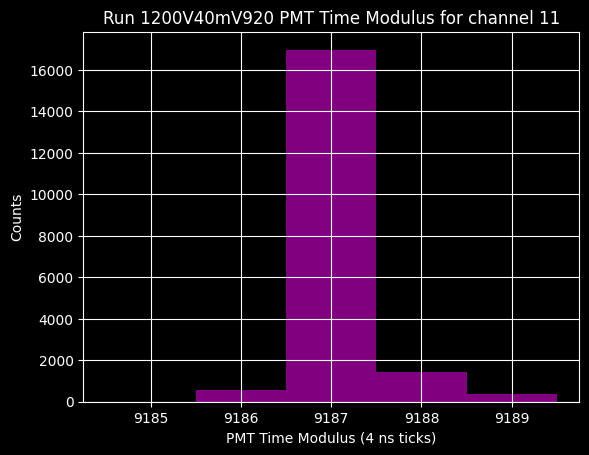

In [106]:
# The distribution of TDC start values shown above are missing the next higher bit
# Use the known period of flashes
clock_period = period / 4  # in units of 4 ns clock ticks that defines the fine time
# choose a block which TDC start values are centered around 8
ic = 0
ib = 5
# find the modulus of pmt_time with respect to the clock period
pmt_time_modulus = corrected_pmt_time_values % clock_period
# find the unique values and their counts
unique, counts = np.unique(pmt_time_modulus, return_counts=True)
# find the values having at least 20 counts and save the minimum and maximum modulus values
mask_count = (counts >= 20)
min_modulus = unique[mask_count][0]
max_modulus = unique[mask_count][-1]
print(f'Minimum significant modulus: {min_modulus}, Maximum significant modulus: {max_modulus}')
for i in range(1, len(unique[mask_count])):
    print(f'Difference: {unique[mask_count][i]-unique[mask_count][i-1]} between {unique[mask_count][i-1]} and {unique[mask_count][i]}')

# choose the modulus with the most events
selected_pmt_time_modulus = unique[np.argmax(counts)]

bins = np.arange(selected_pmt_time_modulus-2, selected_pmt_time_modulus+4, 1)
# show the distribution of the modulus values over that range
plt.hist(pmt_time_modulus, bins=bins, color='purple', align='left')
plt.xlabel('PMT Time Modulus (4 ns ticks)')
plt.ylabel('Counts')
plt.title(f'Run {run_name} PMT Time Modulus for channel {channels[ic]}')
plt.grid(True)
plt.savefig(f'I:/fd2_analyses/corrected_pmt_time_modulus_run{run_name}_chan{channels[ic]:02d}_block{ib}.png')
plt.show()

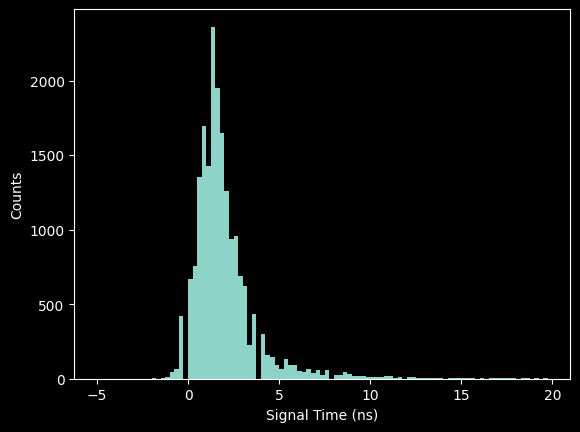

In [109]:
# Look at the signal times for the events near the expected LED flash time

mask = (channel_values == channels[ic])
pmt_time_modulus_zeroed = corrected_pmt_time_values[mask] % clock_period - selected_pmt_time_modulus
signal_times = pmt_time_modulus_zeroed * 4 + tdc_start_values[mask]/4.  # in ns
plt.hist(signal_times,bins=np.arange(-5.,20.,0.25))
plt.xlabel('Signal Time (ns)')
plt.ylabel('Counts')
plt.show()

In [89]:
# Break the events into block of ADC. Assume the amplitude zero point is at ADC=250. Use amplitude bins of width 10, starting at 10 and ending at 160.
# Show the signal time distribution for each amplitude bin in a separate subplot (3 rows, 5 columns). Use the same time bins for each plot, from -5 to 20 ns in steps of 0.25 ns. Fit the distributions to a Gaussian within the range of 0 and 4 ns and show the mean and sigma of the fit in the title of each subplot. Save the results of the means and standard deviations for each amplitude bin in a list.

def gaussian(x, a, mean, sigma):
    return a * np.exp(-0.5 * ((x - mean) / sigma)**2)

mask = (channel_values == channels[ic])
pmt_time_modulus_zeroed = corrected_pmt_time_values[mask] % clock_period - selected_pmt_time_modulus
signal_times = pmt_time_modulus_zeroed * 4 + tdc_start_values[mask]/4.  # in ns

adc_bin_low = np.arange(10, 150, 10)
adc_bin_high = adc_bin_low + 10
fig, axs = plt.subplots(3, 5, figsize=(15, 5))

for index, (adc_bin_low,adc_bin_high) in enumerate(zip(adc_bin_low, adc_bin_high)):
    mask2 = ((adc_values[mask]>=adc_bin_low) & (adc_values[mask]<=adc_bin_high))
    signal_times_bin  = signal_times[mask2]
    # make histogram
    axis = axs[index//5, index%5]
    axis.hist(signal_times_bin, bins=np.arange(-5.,20.,0.25), color='orange')
    axis.set_title(f'ADC {adc_bin_low}-{adc_bin_high}')
    axis.set_xlabel('Signal Time (ns)')
    axis.set_ylabel('Counts')
    axis.grid(True)
    # fit to a Gaussian between 0 and 4 ns
    fit_mask = (signal_times_bin >= 0) & (signal_times_bin <= 4)
    if np.sum(fit_mask) > 10:  # require at least 10 events to fit
        hist, bin_edges = np.histogram(signal_times_bin[fit_mask], bins=np.arange(0, 4, 0.25))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2





4834